# Post Engagement Predictor — ML Pipeline

**BYU IS Class Project — Lighthouse Philippines**

This notebook builds both an **explanatory** and **predictive** model to answer:
> *What social media post attributes drive engagement (likes, shares, comments)?*
> *Are high-engagement posts also high-donation posts — or do vanity metrics mislead strategy?*

## 1. Problem Framing

**Business Problem:**
Lighthouse Sanctuary operates safehouses for girls who are survivors of abuse and trafficking in the Philippines. The organization posts across 7 social media platforms (Facebook, Instagram, Twitter, WhatsApp, TikTok, LinkedIn, YouTube — **812 posts total**) to raise awareness and drive donations.

The companion notebook (`social-media-donation-driver`) predicts **donation value**. This notebook predicts **total engagement** (likes + shares + comments) and then contrasts the two: do the same post attributes that drive engagement also drive donations, or is "going viral" a vanity metric that distracts from fundraising?

**Key Questions:**
1. What post attributes (platform, content type, media type, timing, hashtags, etc.) drive total engagement?
2. How well can we predict engagement for a new post?
3. Do engagement-optimized posts also maximize donations, or is there a disconnect?

**Modeling Strategy — Two Complementary Approaches:**

| Approach | Goal | Method |
|----------|------|--------|
| **Explanatory** | Understand *what drives* engagement | OLS Regression (statsmodels) |
| **Predictive** | Predict engagement for *new* posts | LinearRegression, RandomForest, GradientBoosting (sklearn) |

**Target variable:** `total_engagement` = likes + shares + comments (continuous, regression task)
**Unit of analysis:** One social media post (n = 812)

## 2. Data Preparation

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from scipy.stats import spearmanr

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# ── Load data ────────────────────────────────────────────────────────────────────
DATA_PATH = "../LighthouseData/"
sm_posts = pd.read_csv(DATA_PATH + "social_media_posts.csv")
print(f"Shape: {sm_posts.shape}")
print(f"Columns: {sm_posts.columns.tolist()}")

# ── Engineer target: total_engagement ─────────────────────────────────────────
sm_posts["total_engagement"] = (
    sm_posts["likes"].fillna(0)
    + sm_posts["shares"].fillna(0)
    + sm_posts["comments"].fillna(0)
)
print(f"\nTarget — total_engagement (likes + shares + comments):")
print(sm_posts["total_engagement"].describe())
print(f"\nZero-engagement posts: {(sm_posts['total_engagement'] == 0).sum()}")

# ── Feature engineering ────────────────────────────────────────────────────────
sm_posts["has_campaign"] = sm_posts["campaign_name"].notna().astype(int)

CATEGORICAL_FEATURES = [
    "platform", "post_type", "media_type", "sentiment_tone",
    "content_topic", "day_of_week", "call_to_action_type"
]
NUMERIC_FEATURES = [
    "post_hour", "num_hashtags", "caption_length", "mentions_count"
]
BINARY_FEATURES = [
    "has_call_to_action", "features_resident_story", "is_boosted", "has_campaign"
]
TARGET = "total_engagement"
ALL_FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES + BINARY_FEATURES

for col in BINARY_FEATURES:
    sm_posts[col] = sm_posts[col].astype(int)

# ── Handle missing values & prepare X, y ────────────────────────────────────
df = sm_posts.dropna(subset=[TARGET]).copy()
print(f"\nRows after dropping missing target: {len(df)}")

for col in CATEGORICAL_FEATURES:
    df[col] = df[col].fillna("Unknown")
for col in NUMERIC_FEATURES:
    df[col] = df[col].fillna(df[col].median())

X = df[ALL_FEATURES]
y = df[TARGET]

# ── Train/Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

Shape: (812, 39)
Columns: ['post_id', 'platform', 'platform_post_id', 'post_url', 'created_at', 'day_of_week', 'post_hour', 'post_type', 'media_type', 'caption', 'hashtags', 'num_hashtags', 'mentions_count', 'has_call_to_action', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'caption_length', 'features_resident_story', 'campaign_name', 'is_boosted', 'boost_budget_php', 'impressions', 'reach', 'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views', 'engagement_rate', 'profile_visits', 'donation_referrals', 'estimated_donation_value_php', 'follower_count_at_post', 'watch_time_seconds', 'avg_view_duration_seconds', 'subscriber_count_at_post', 'forwards']

Target — total_engagement (likes + shares + comments):
count     812.000000
mean      515.359606
std       763.473961
min         1.000000
25%        77.750000
50%       236.000000
75%       604.250000
max      7154.000000
Name: total_engagement, dtype: float64

Zero-engagement posts: 0

Rows after dropping m

## 3. Exploratory Data Analysis

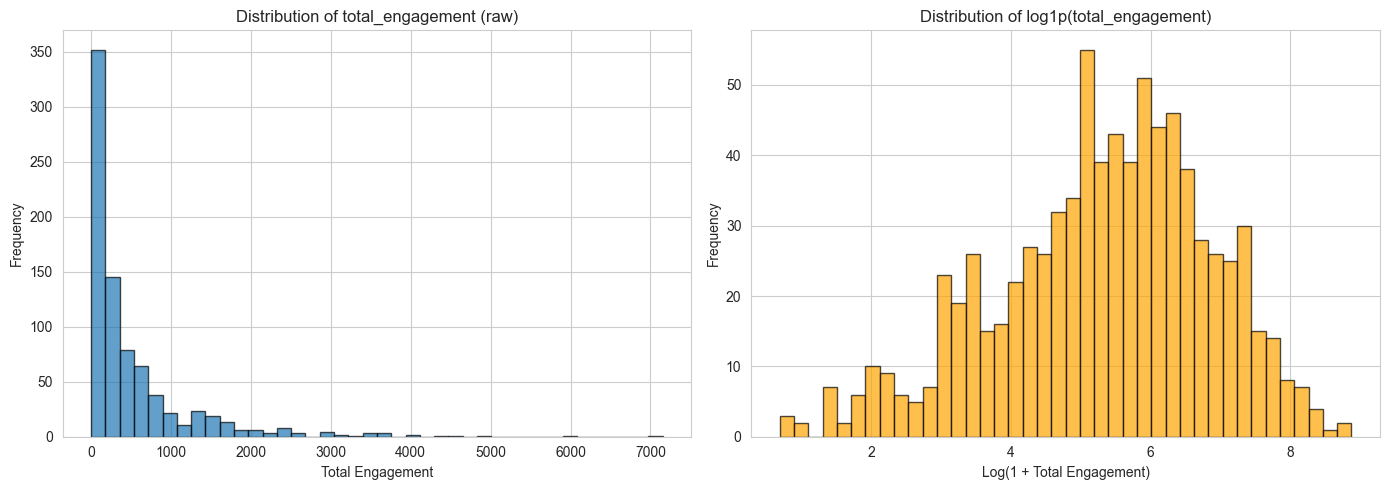

Skewness (raw):  3.33
Skewness (log):  -0.46


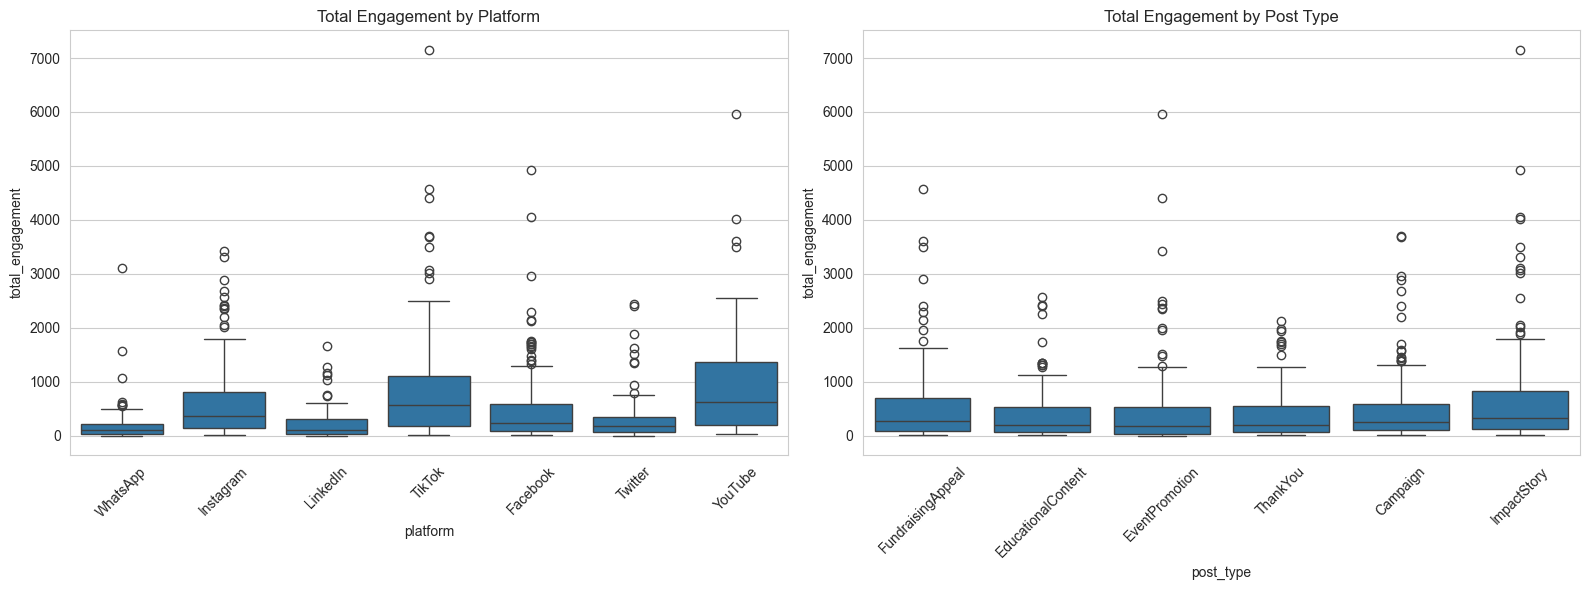


Top correlations with total_engagement:
likes             0.988978
forwards          0.963501
saves             0.936350
shares            0.918213
comments          0.917753
profile_visits    0.916495
reach             0.830387
impressions       0.807779
click_throughs    0.750235
video_views       0.711969
Name: total_engagement, dtype: float64


In [2]:
# ── Target distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sm_posts["total_engagement"].dropna(), bins=40, edgecolor="k", alpha=0.7)
axes[0].set_title("Distribution of total_engagement (raw)")
axes[0].set_xlabel("Total Engagement")
axes[0].set_ylabel("Frequency")

log_target = np.log1p(sm_posts["total_engagement"].dropna())
axes[1].hist(log_target, bins=40, edgecolor="k", alpha=0.7, color="orange")
axes[1].set_title("Distribution of log1p(total_engagement)")
axes[1].set_xlabel("Log(1 + Total Engagement)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()
print(f"Skewness (raw):  {sm_posts['total_engagement'].skew():.2f}")
print(f"Skewness (log):  {log_target.skew():.2f}")

# ── Engagement by platform and post type ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=sm_posts, x="platform", y="total_engagement", ax=axes[0])
axes[0].set_title("Total Engagement by Platform")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=sm_posts, x="post_type", y="total_engagement", ax=axes[1])
axes[1].set_title("Total Engagement by Post Type")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# ── Correlation with target ────────────────────────────────────────────────────
numeric_cols = sm_posts.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = sm_posts[numeric_cols].corr()["total_engagement"].drop("total_engagement").sort_values(ascending=False)
print("\nTop correlations with total_engagement:")
print(corr_with_target.head(10))

## 4. Explanatory Model — OLS Regression (statsmodels)

                            OLS Regression Results                            
Dep. Variable:       total_engagement   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     16.18
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           9.54e-77
Time:                        20:36:48   Log-Likelihood:                -942.76
No. Observations:                 649   AIC:                             1978.
Df Residuals:                     603   BIC:                             2183.
Df Model:                          45                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

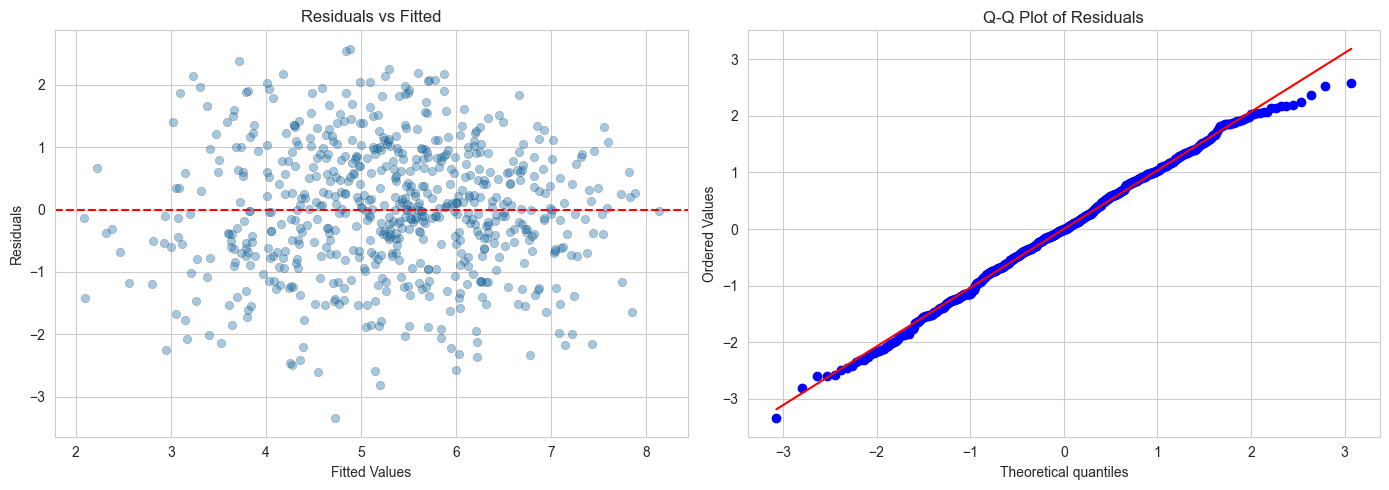

Breusch-Pagan Test for Heteroscedasticity:
  LM Statistic: 57.5389
  LM p-value: 0.1184
  F-Statistic: 1.3036
  F p-value: 0.0932

Variance Inflation Factors:
                Feature      VIF
         caption_length 1.081422
     has_call_to_action 1.077708
features_resident_story 1.076798
           num_hashtags 1.069085
           has_campaign 1.025353
             is_boosted 1.012200
         mentions_count 1.008723
              post_hour 1.008449

OLS Test Performance:  R2=0.1776  RMSE=596.78  MAE=320.95


In [3]:
# ── OLS Regression with log-transformed target ───────────────────────────────
X_train_dummies = pd.get_dummies(X_train, columns=CATEGORICAL_FEATURES, drop_first=True)
X_test_dummies  = pd.get_dummies(X_test,  columns=CATEGORICAL_FEATURES, drop_first=True)
X_test_dummies = X_test_dummies.reindex(columns=X_train_dummies.columns, fill_value=0)

y_log_train = np.log1p(y_train)

# pd.to_numeric fix for mixed-type dummy columns
X_train_dummies = X_train_dummies.apply(pd.to_numeric, errors='coerce').fillna(0)
X_exp = sm.add_constant(X_train_dummies.astype(float))
ols_model = sm.OLS(y_log_train.astype(float), X_exp).fit()
print(ols_model.summary())

# ── OLS Diagnostics ────────────────────────────────────────────────────────────
fitted = ols_model.fittedvalues
residuals = ols_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(fitted, residuals, alpha=0.4, edgecolors="k", linewidths=0.3)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

bp_test = het_breuschpagan(residuals, X_exp)
labels = ["LM Statistic", "LM p-value", "F-Statistic", "F p-value"]
print("Breusch-Pagan Test for Heteroscedasticity:")
for label, val in zip(labels, bp_test):
    print(f"  {label}: {val:.4f}")

# ── VIF ─────────────────────────────────────────────────────────────────────────
vif_features = NUMERIC_FEATURES + BINARY_FEATURES
vif_data = sm.add_constant(X_train_dummies[vif_features].copy())
vif_results = pd.DataFrame({
    "Feature": vif_features,
    "VIF": [variance_inflation_factor(vif_data.values, i + 1) for i in range(len(vif_features))]
}).sort_values("VIF", ascending=False)
print("\nVariance Inflation Factors:")
print(vif_results.to_string(index=False))

# ── OLS test-set performance ─────────────────────────────────────────────────
X_test_dummies = X_test_dummies.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_exp = sm.add_constant(X_test_dummies.astype(float))
y_pred_ols = np.maximum(np.expm1(ols_model.predict(X_test_exp)), 0)

ols_r2 = r2_score(y_test, y_pred_ols)
ols_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
ols_mae = mean_absolute_error(y_test, y_pred_ols)
print(f"\nOLS Test Performance:  R2={ols_r2:.4f}  RMSE={ols_rmse:.2f}  MAE={ols_mae:.2f}")

## 5. Predictive Model — sklearn Pipeline

In [4]:
# ── Preprocessing ColumnTransformer ────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUMERIC_FEATURES + BINARY_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES)
])

# ── Model comparison with cross-validation ─────────────────────────────────
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results.append({"Model": name, "CV_R2_mean": cv_scores.mean(),
                    "CV_R2_std": cv_scores.std(), "Test_MAE": mae,
                    "Test_RMSE": rmse, "Test_R2": r2})
    print(f"{name:25s}  CV R2={cv_scores.mean():.4f} (+/-{cv_scores.std():.4f})  "
          f"Test R2={r2:.4f}  MAE={mae:.2f}  RMSE={rmse:.2f}")

results_df = pd.DataFrame(results).sort_values("Test_R2", ascending=False)

# ── Refit best model ───────────────────────────────────────────────────────────
best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42))
])
best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)
print(f"\nBest Model: GradientBoosting  MAE={mean_absolute_error(y_test, y_pred_best):.2f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}  "
      f"R2={r2_score(y_test, y_pred_best):.4f}")

LinearRegression           CV R2=0.2579 (+/-0.0231)  Test R2=0.2969  MAE=367.59  RMSE=551.77
RandomForest               CV R2=0.2440 (+/-0.0606)  Test R2=0.2795  MAE=318.11  RMSE=558.56
GradientBoosting           CV R2=0.2710 (+/-0.0975)  Test R2=0.4229  MAE=291.18  RMSE=499.89

Best Model: GradientBoosting  MAE=291.18  RMSE=499.89  R2=0.4229


## 6. Evaluation

Full Model Comparison (Test Set):
           Model   Test_MAE  Test_RMSE  Test_R2
GradientBoosting 291.180228 499.891239 0.422936
LinearRegression 367.590328 551.769515 0.296947
    RandomForest 318.108914 558.562811 0.279528
 OLS_Explanatory 320.946346 596.780941 0.177563


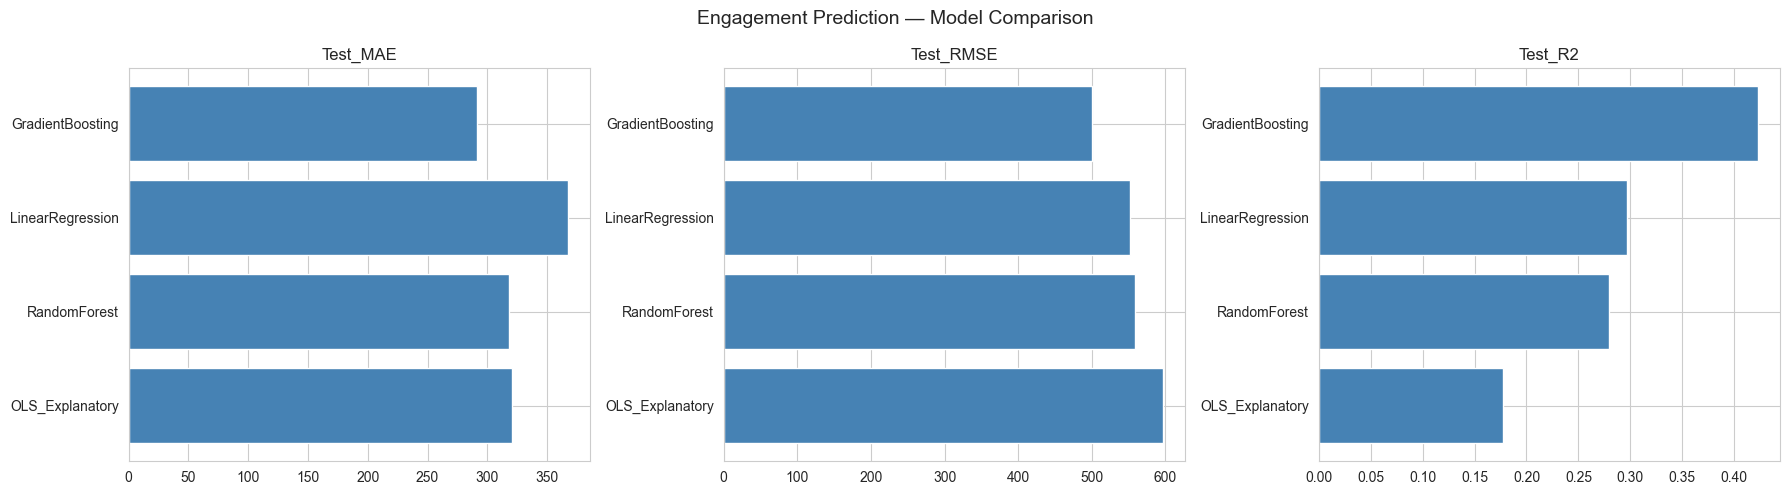

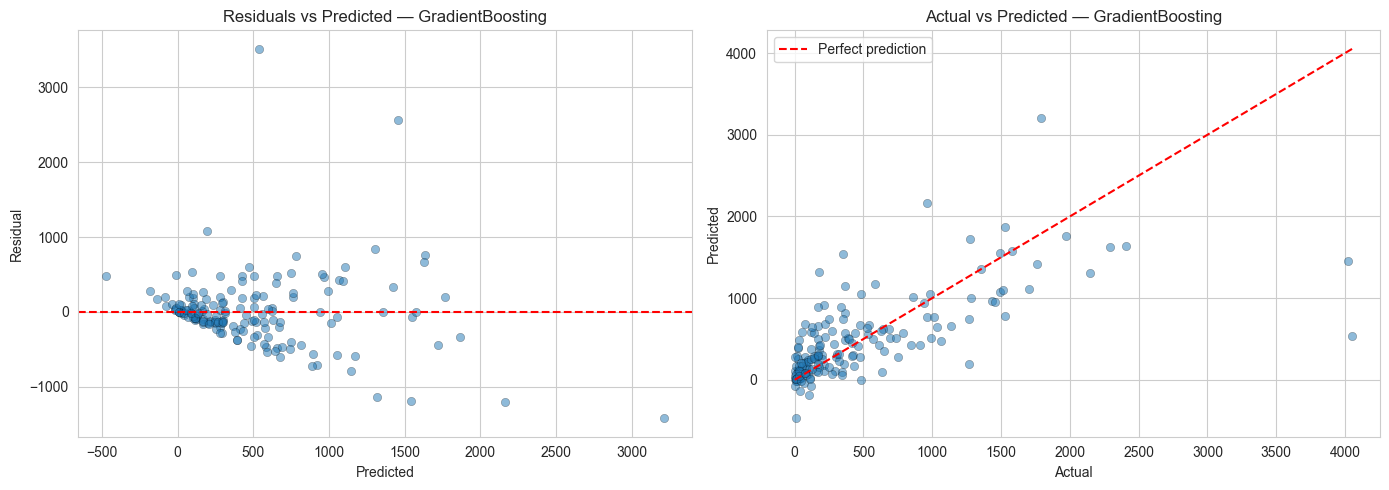

In [5]:
# ── Model comparison table ─────────────────────────────────────────────────────
comparison = pd.concat([results_df, pd.DataFrame([{
    "Model": "OLS_Explanatory", "CV_R2_mean": np.nan, "CV_R2_std": np.nan,
    "Test_MAE": ols_mae, "Test_RMSE": ols_rmse, "Test_R2": ols_r2
}])], ignore_index=True)
print("Full Model Comparison (Test Set):")
print(comparison[["Model", "Test_MAE", "Test_RMSE", "Test_R2"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(["Test_MAE", "Test_RMSE", "Test_R2"]):
    axes[i].barh(comparison["Model"], comparison[metric], color="steelblue")
    axes[i].set_title(metric); axes[i].invert_yaxis()
plt.suptitle("Engagement Prediction — Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

# ── Residual plot for best model ──────────────────────────────────────────────
residuals_best = y_test - y_pred_best
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_best, residuals_best, alpha=0.5, edgecolors="k", linewidths=0.3)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted — GradientBoosting")

axes[1].scatter(y_test, y_pred_best, alpha=0.5, edgecolors="k", linewidths=0.3)
max_val = max(y_test.max(), y_pred_best.max())
axes[1].plot([0, max_val], [0, max_val], "r--", label="Perfect prediction")
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted")
axes[1].set_title("Actual vs Predicted — GradientBoosting")
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Causal and Relationship Analysis — Vanity Metrics vs Donation Drivers

**Important caveat:** This is observational data — we cannot claim that changing post features *causes* different engagement levels. Posts are created by humans who choose platform, content type, and timing based on strategy, creating selection bias.

**Key relationships to examine:**
- Which features drive engagement vs. which drive donations (from the companion notebook)?
- Is high engagement a "vanity metric" that doesn't convert to donations?
- Are the relationships causal or merely correlational?

All findings below are **correlational**. A/B testing would be needed to establish causation.

Significant coefficients (p < 0.05): 15 out of 47

                             Coefficient       p_value
const                           2.651912  5.224388e-20
has_call_to_action              1.384505  3.492404e-18
call_to_action_type_Unknown     1.267407  5.410434e-15
is_boosted                      1.159938  6.775654e-21
platform_YouTube                0.629862  7.628725e-04
features_resident_story         0.557945  9.343026e-03
media_type_Reel                 0.403106  3.773809e-02
platform_Instagram              0.319345  1.746537e-02
post_hour                       0.109215  3.332503e-48
mentions_count                  0.108159  3.226645e-02
sentiment_tone_Hopeful         -0.405078  7.368327e-03
sentiment_tone_Grateful        -0.452019  4.486964e-03
media_type_Text                -0.651527  2.142198e-04
platform_WhatsApp              -0.741067  4.469305e-05
sentiment_tone_Informative     -0.987397  1.357353e-10


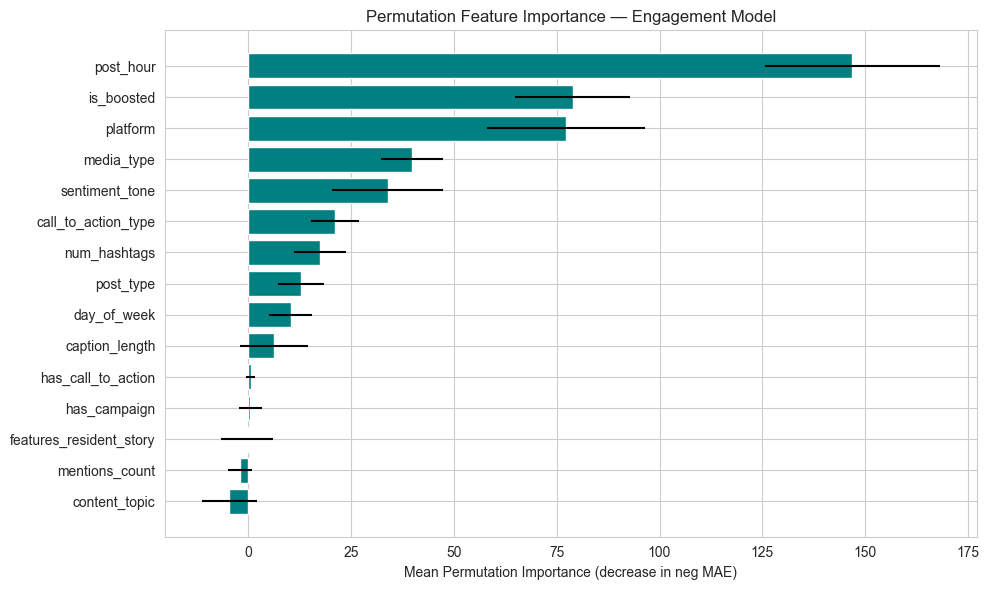

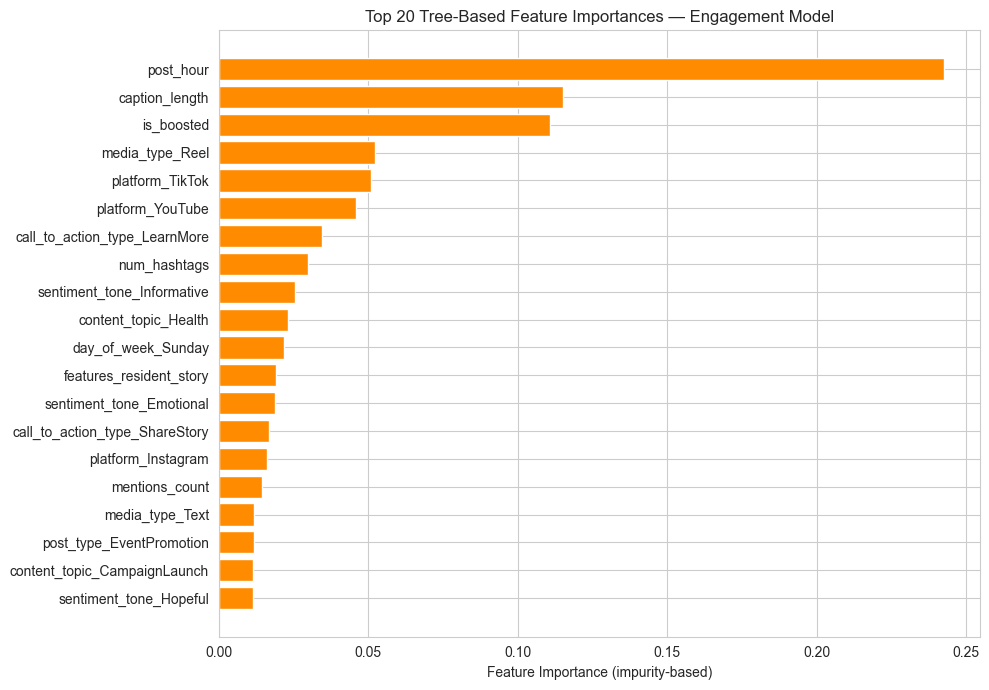


Spearman rho (engagement vs donation value): 0.683  (p = 1.01e-112)


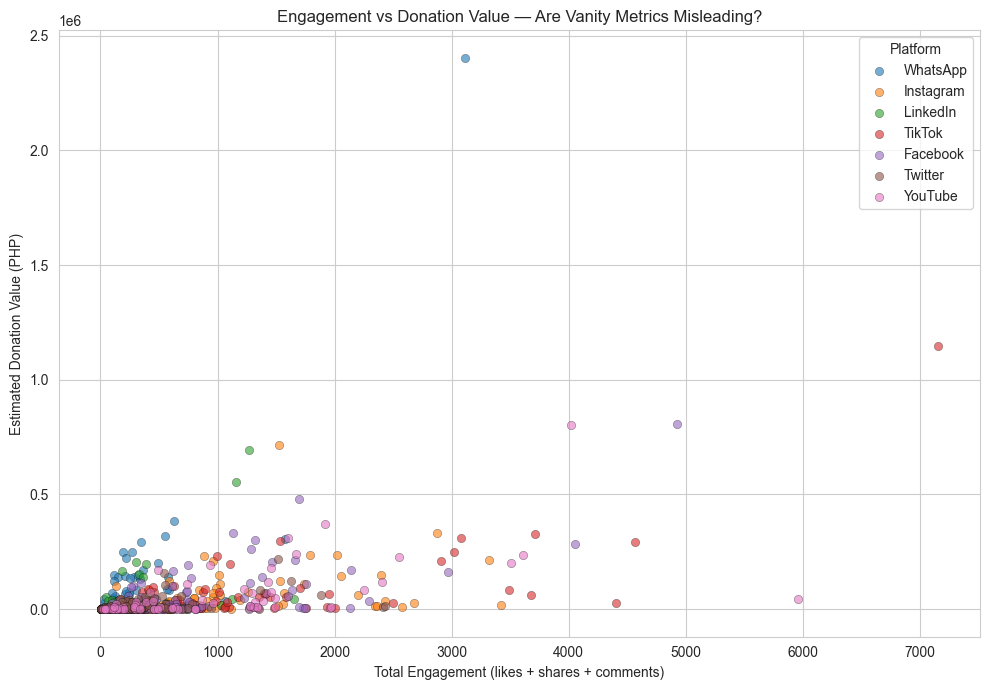


Spearman rho by platform:
  Facebook      rho = 0.71  (p = 0.000)
  Instagram     rho = 0.70  (p = 0.000)
  LinkedIn      rho = 0.61  (p = 0.000)
  TikTok        rho = 0.75  (p = 0.000)
  Twitter       rho = 0.66  (p = 0.000)
  WhatsApp      rho = 0.84  (p = 0.000)
  YouTube       rho = 0.74  (p = 0.000)

KEY FINDINGS: ENGAGEMENT vs DONATION DRIVERS

Top features that INCREASE engagement (significant OLS coefficients):
  const                                     coef = +2.652  (p = 0.0000)
  has_call_to_action                        coef = +1.385  (p = 0.0000)
  call_to_action_type_Unknown               coef = +1.267  (p = 0.0000)
  is_boosted                                coef = +1.160  (p = 0.0000)
  platform_YouTube                          coef = +0.630  (p = 0.0008)
  features_resident_story                   coef = +0.558  (p = 0.0093)
  media_type_Reel                           coef = +0.403  (p = 0.0377)
  platform_Instagram                        coef = +0.319  (p = 0.0175)


In [6]:
# ── OLS coefficient interpretation ────────────────────────────────────────────
sig_coefs = ols_model.pvalues[ols_model.pvalues < 0.05]
print(f"Significant coefficients (p < 0.05): {len(sig_coefs)} out of {len(ols_model.params)}\n")
sig_df = pd.DataFrame({
    "Coefficient": ols_model.params[sig_coefs.index],
    "p_value": sig_coefs
}).sort_values("Coefficient", ascending=False)
print(sig_df.to_string())

# ── Permutation feature importance (uses input feature names) ───────────────
perm_imp = permutation_importance(
    best_pipeline, X_test, y_test, n_repeats=20, random_state=42,
    scoring="neg_mean_absolute_error"
)
perm_df = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Importance_Mean": perm_imp.importances_mean,
    "Importance_Std": perm_imp.importances_std
}).sort_values("Importance_Mean", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(perm_df["Feature"], perm_df["Importance_Mean"],
         xerr=perm_df["Importance_Std"], color="teal")
plt.xlabel("Mean Permutation Importance (decrease in neg MAE)")
plt.title("Permutation Feature Importance — Engagement Model")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ── Tree-based feature importance (uses OHE-expanded names) ─────────────────
gb_model = best_pipeline.named_steps["regressor"]
ohe = best_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERIC_FEATURES + BINARY_FEATURES + cat_feature_names

tree_imp_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": gb_model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(tree_imp_df["Feature"], tree_imp_df["Importance"], color="darkorange")
plt.xlabel("Feature Importance (impurity-based)")
plt.title("Top 20 Tree-Based Feature Importances — Engagement Model")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ── Engagement vs Donation Value ───────────────────────────────────────────────
rho, p_val = spearmanr(
    sm_posts["total_engagement"].dropna(),
    sm_posts.loc[sm_posts["total_engagement"].notna(), "estimated_donation_value_php"]
)
print(f"\nSpearman rho (engagement vs donation value): {rho:.3f}  (p = {p_val:.2e})")

fig, ax = plt.subplots(figsize=(10, 7))
for platform in sm_posts["platform"].unique():
    subset = sm_posts[sm_posts["platform"] == platform]
    ax.scatter(subset["total_engagement"], subset["estimated_donation_value_php"],
               label=platform, alpha=0.6, edgecolors="k", linewidths=0.3)
ax.set_xlabel("Total Engagement (likes + shares + comments)")
ax.set_ylabel("Estimated Donation Value (PHP)")
ax.set_title("Engagement vs Donation Value — Are Vanity Metrics Misleading?")
ax.legend(title="Platform")
plt.tight_layout()
plt.show()

print("\nSpearman rho by platform:")
for platform in sorted(sm_posts["platform"].unique()):
    subset = sm_posts[sm_posts["platform"] == platform].dropna(
        subset=["total_engagement", "estimated_donation_value_php"])
    if len(subset) > 5:
        rho_p, p_p = spearmanr(subset["total_engagement"], subset["estimated_donation_value_php"])
        print(f"  {platform:12s}  rho = {rho_p:.2f}  (p = {p_p:.3f})")

# ── Key findings summary ───────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("KEY FINDINGS: ENGAGEMENT vs DONATION DRIVERS")
print("=" * 70)
print("\nTop features that INCREASE engagement (significant OLS coefficients):")
sig_positive = sig_df[sig_df["Coefficient"] > 0].head(10)
for idx, row in sig_positive.iterrows():
    print(f"  {idx:40s}  coef = {row['Coefficient']:+.3f}  (p = {row['p_value']:.4f})")

print("\nTop features that DECREASE engagement:")
sig_negative = sig_df[sig_df["Coefficient"] < 0].head(10)
for idx, row in sig_negative.iterrows():
    print(f"  {idx:40s}  coef = {row['Coefficient']:+.3f}  (p = {row['p_value']:.4f})")

print("\n" + "=" * 70)
print("VANITY METRICS INSIGHT")
print("=" * 70)
print("""
Compare these engagement drivers with the donation drivers from the
companion notebook (social-media-donation-driver). Key contrasts:

1. Posts that go viral (high engagement) may emphasize emotional/shareable
   content, but donation-driving posts often need a clear call-to-action
   and specific ask amount.

2. Platform differences: a platform that generates high engagement (e.g.,
   TikTok/Instagram) may not be the same platform that drives donations
   (e.g., Facebook/LinkedIn with older, higher-income audiences).

3. Content type: ImpactStory posts may drive both engagement AND donations,
   but ThankYou posts may get engagement (emotional response) without
   converting to donations.

4. Recommendation: Optimize for DONATIONS, not engagement. Use engagement
   metrics for awareness/reach goals, but track donation referrals as the
   true KPI for fundraising posts.
""")

## 8. Deployment Notes

**Integration:** Engagement predictions appear on the **Reports & Analytics** page alongside social media post metrics. The model helps the communications team identify which post types will generate the most engagement.

**Endpoint:** `POST /api/ml/engagement-prediction` accepts post features and returns predicted total engagement (likes + shares + comments).

**How it works:**
1. Post features (platform, content type, day of week, has image/video) are preprocessed using the pipeline from Section 5
2. The Gradient Boosting regressor predicts log-transformed engagement, then inverse-transforms
3. Predictions are shown in a "Predicted Engagement" column when drafting new posts

**Retraining:** Re-run when 100+ new posts are available.

## 9. Summary & Recommendations

### Actionable Recommendations

1. **Do not optimize solely for engagement.** High-engagement posts (viral content, memes, emotional stories) may not convert to donations. Track donation referrals as the true fundraising KPI.

2. **Use engagement strategically for awareness.** Engagement-optimized posts are valuable for growing reach and follower count, which builds the top of the donation funnel.

3. **Segment your content strategy:**
   - **Awareness posts** — optimize for engagement (shares, likes) to grow audience
   - **Fundraising posts** — optimize for donation referrals with clear CTAs and specific ask amounts

4. **Platform-specific strategy:** If engagement-to-donation correlation varies by platform, allocate fundraising content to high-conversion platforms and awareness content to high-engagement platforms.

5. **A/B test to confirm:** Alternate engagement-optimized vs donation-optimized posts on the same platform and measure actual donation outcomes.

**Limitations:**
- Observational data — all findings are correlational, not causal
- 812 posts is moderate; model stability improves with more data
- Engagement metrics may be inflated by bots or paid boosts
- The "vanity metrics" analysis depends on the companion donation-driver model's accuracy